# Task 3: Data Visualization (Python) — Day 14-15

This notebook creates:
1. Matplotlib plots (line, bar, scatter, histogram)
2. Seaborn advanced plots (heatmap, pairplot, boxen)
3. Interactive Plotly plots
4. Exports everything as PNG/HTML for your GitHub deliverable

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Folder to save exported charts
os.makedirs("../reports/charts", exist_ok=True)

In [3]:
df = pd.read_csv("../data/cleaned_superstore_sales.csv")

# Standardize column names (same as Task 2)
df.columns = [c.strip().lower().replace(" ", "_").replace("-", "_") for c in df.columns]
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,sales_outlier
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,False
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,True
2,3,CA-2016-138688,2016-06-12,NaN,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,False
3,4,US-2015-108966,2015-10-11,NaN,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,True
4,5,US-2015-108966,2015-10-11,NaN,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,False


## 1. Matplotlib: Line chart — Monthly Sales Trend

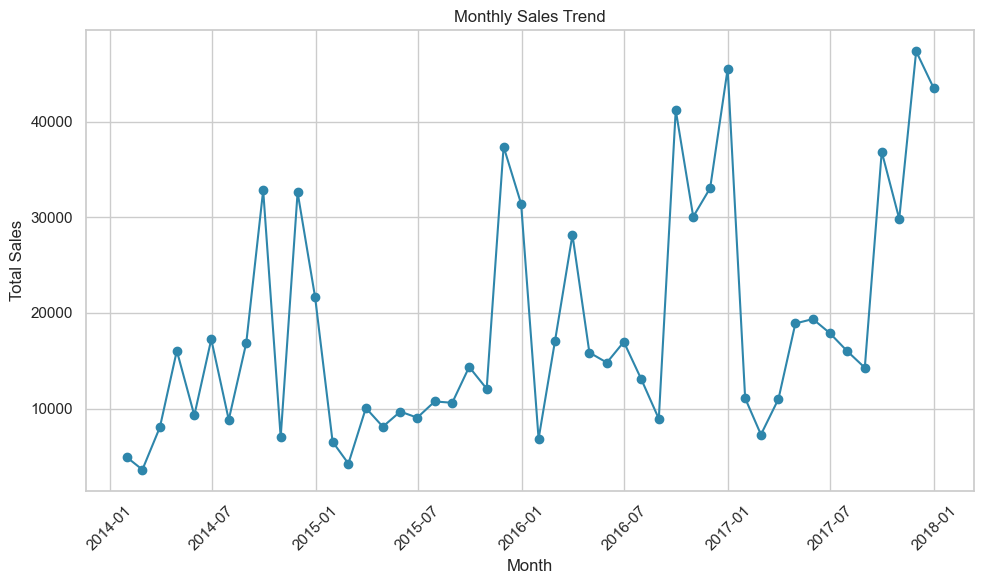

In [4]:
monthly_sales = df.set_index("order_date").resample("ME")["sales"].sum()

plt.figure()
plt.plot(monthly_sales.index, monthly_sales.values, marker="o", color="#2E86AB")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../reports/charts/01_monthly_sales_trend.png", dpi=150)
plt.show()

## 2. Matplotlib: Bar chart — Sales by Category

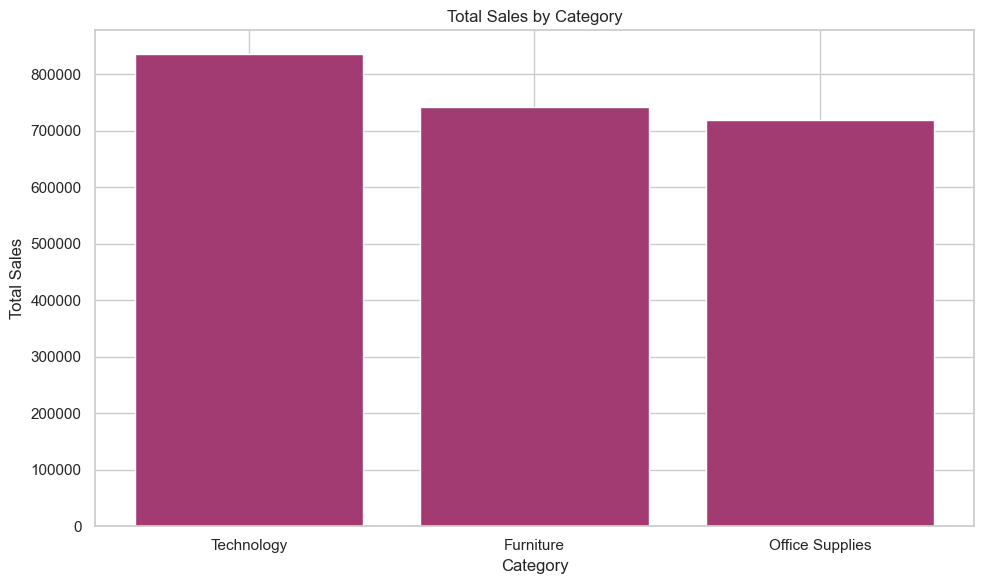

In [5]:
category_sales = df.groupby("category")["sales"].sum().sort_values(ascending=False)

plt.figure()
plt.bar(category_sales.index, category_sales.values, color="#A23B72")
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.savefig("../reports/charts/02_sales_by_category.png", dpi=150)
plt.show()

## 3. Matplotlib: Scatter plot — Sales vs Discount

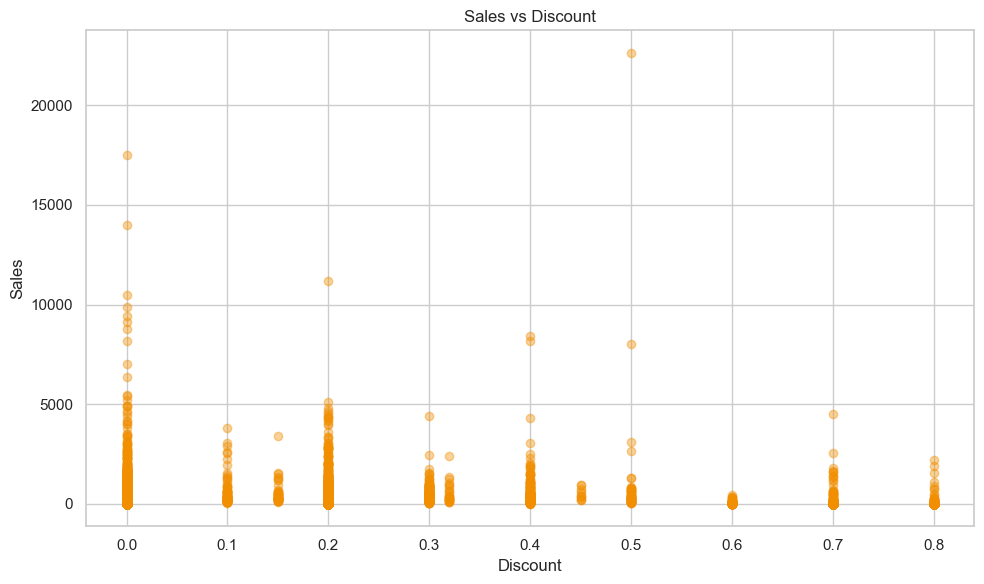

In [6]:
plt.figure()
plt.scatter(df["discount"], df["sales"], alpha=0.4, color="#F18F01")
plt.title("Sales vs Discount")
plt.xlabel("Discount")
plt.ylabel("Sales")
plt.tight_layout()
plt.savefig("../reports/charts/03_sales_vs_discount.png", dpi=150)
plt.show()

## 4. Matplotlib: Histogram — Sales Distribution

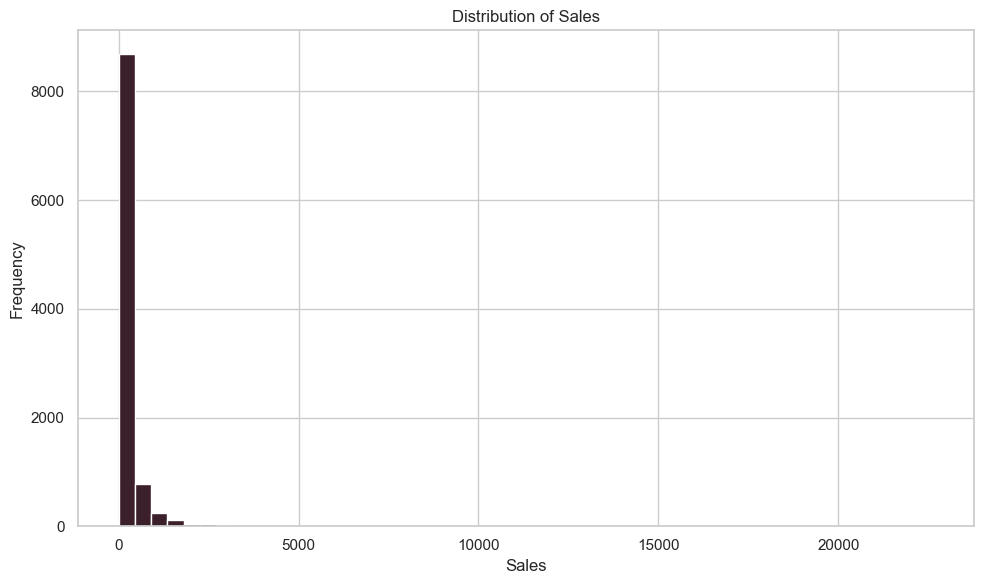

In [7]:
plt.figure()
plt.hist(df["sales"], bins=50, color="#3B1F2B")
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("../reports/charts/04_sales_distribution.png", dpi=150)
plt.show()

## 5. Seaborn: Heatmap — Correlation Matrix

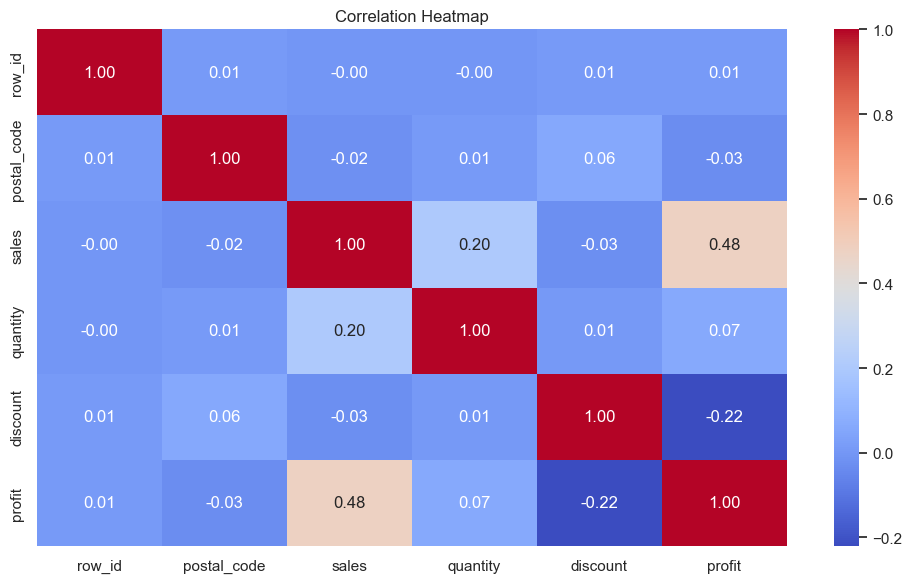

In [8]:
plt.figure()
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("../reports/charts/05_correlation_heatmap.png", dpi=150)
plt.show()

## 6. Seaborn: Pairplot — Relationships Between Numeric Columns

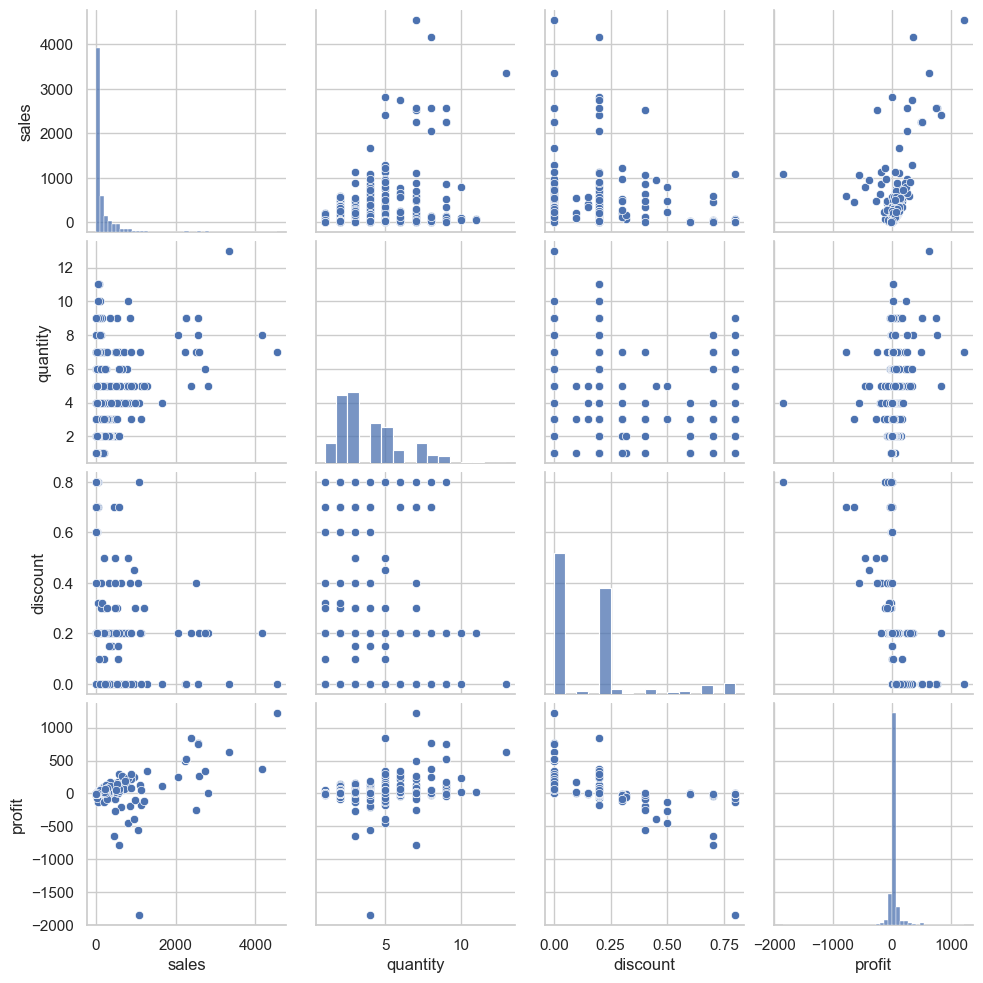

In [9]:
# Pairplot can be slow on large datasets, so we sample 500 rows
sample_df = df.sample(min(500, len(df)), random_state=42)

pair_cols = [c for c in ["sales", "quantity", "discount", "profit"] if c in df.columns]
g = sns.pairplot(sample_df[pair_cols])
g.savefig("../reports/charts/06_pairplot.png", dpi=150)

## 7. Seaborn: Boxen plot — Sales Distribution by Region

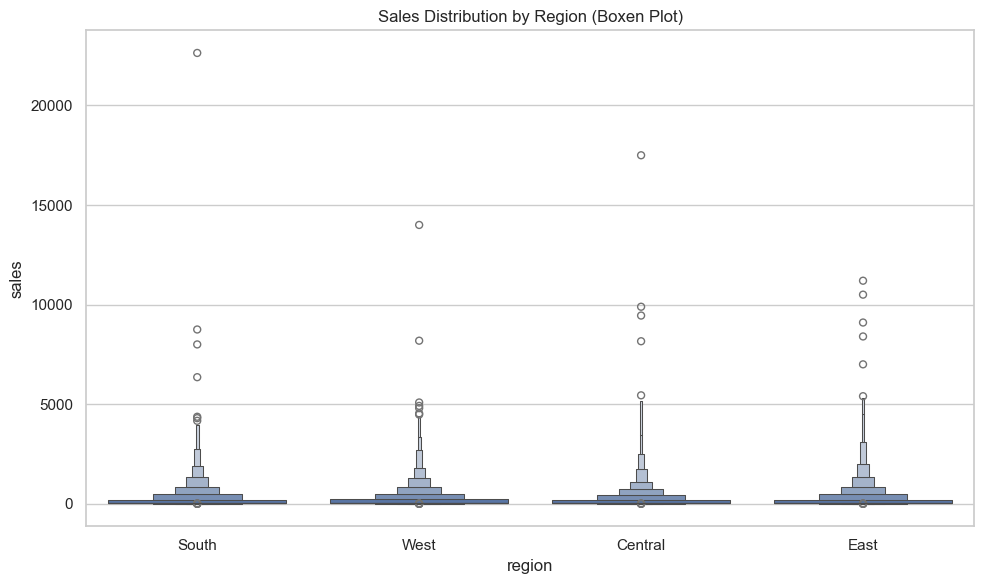

In [10]:
plt.figure()
sns.boxenplot(x="region", y="sales", data=df)
plt.title("Sales Distribution by Region (Boxen Plot)")
plt.tight_layout()
plt.savefig("../reports/charts/07_boxen_region.png", dpi=150)
plt.show()

## 8. Plotly: Interactive Bar Chart — Sales by Region

In [11]:
region_sales = df.groupby("region", as_index=False)["sales"].sum()

fig = px.bar(region_sales, x="region", y="sales", title="Total Sales by Region (Interactive)",
             color="region", text_auto=True)
fig.write_html("../reports/charts/08_sales_by_region_interactive.html")
fig.show()

## 9. Plotly: Interactive Line Chart — Monthly Sales Trend

In [12]:
monthly_df = monthly_sales.reset_index()
monthly_df.columns = ["order_date", "sales"]

fig2 = px.line(monthly_df, x="order_date", y="sales", title="Monthly Sales Trend (Interactive)",
               markers=True)
fig2.write_html("../reports/charts/09_monthly_trend_interactive.html")
fig2.show()

## 10. Plotly: Treemap — Category > Sub-Category Sales Breakdown

In [13]:
treemap_data = df.groupby(["category", "sub_category"], as_index=False)["sales"].sum()

fig3 = px.treemap(treemap_data, path=["category", "sub_category"], values="sales",
                   title="Sales Breakdown: Category > Sub-Category")
fig3.write_html("../reports/charts/10_treemap_category.html")
fig3.show()

## Summary

This notebook covers the Python visualization component of Task 3 (Data Visualization & Dashboarding) 
for the ApexPlanet Data Analytics Internship, using the cleaned Superstore Sales dataset.

**What was built:**
- **4 Matplotlib charts** — monthly sales trend (line), sales by category (bar), 
  sales vs. discount (scatter), and sales distribution (histogram)
- **3 Seaborn visualizations** — a correlation heatmap across numeric fields, a pairplot 
  exploring relationships between Sales/Quantity/Discount/Profit, and a boxen plot comparing 
  sales spread across regions
- **3 interactive Plotly charts** — a regional sales bar chart, a monthly sales trend line 
  chart, and a treemap breaking down sales by Category and Sub-Category

**Key techniques used:**
- Grouping and aggregation with `pandas.groupby()`
- Time-series resampling (`resample("ME")`) for monthly trends
- Correlation analysis via `.corr()` and heatmap visualization
- Exporting static charts as PNG and interactive charts as standalone HTML files for sharing 
  outside the notebook


